# KENYA TOP 100 PREDICTION

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv(r'C:\Users\ChristineKakina\PycharmProjects\HitSongPredictor\Kenya.csv')
df = data.copy()


In [111]:
df.head()

,artist,album,track_name,track_id,danceability,energy,key,loudness,mode,speechiness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,Nyashinski,Hello,Hello,5oHGYyIokNKyDvyi4pNu44,0.633,0.695,8,-6.048,1,0.166,0.000000,0.0783,0.605,126.521,230000,5
1,Nyashinski,Properly (feat. Femi One),Properly (feat. Femi One),6zSFJHyjfajlXTSV7p4j0G,0.909,0.560,9,-7.345,1,0.366,0.000000,0.0295,0.704,110.137,196364,4
2,Nyashinski,Hapo Tu (feat. Chris Kaiga),Hapo Tu (feat. Chris Kaiga),6JR3F5nXtkkHwiCHIeYqSC,0.726,0.706,1,-3.448,1,0.343,0.000587,0.0291,0.555,119.896,187556,3
3,Nyashinski,Mungu Pekee,Mungu Pekee,1QgM3SejXDyHkqt0guA4TX,0.718,0.759,0,-4.548,1,0.173,0.000000,0.0624,0.769,100.008,230452,4
4,Nyashinski,Bebi Bebi,Bebi Bebi,4U2PpIPmXV04EyrzNe0Ary,0.708,0.442,1,-8.699,1,0.166,0.000000,0.0456,0.788,146.010,240000,4


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artist            53 non-null     object 
 1   album             53 non-null     object 
 2   track_name        53 non-null     object 
 3   track_id          53 non-null     object 
 4   danceability      53 non-null     float64
 5   energy            53 non-null     float64
 6   key               53 non-null     int64  
 7   loudness          53 non-null     float64
 8   mode              53 non-null     int64  
 9   speechiness       53 non-null     float64
 10  instrumentalness  53 non-null     float64
 11  liveness          53 non-null     float64
 12  valence           53 non-null     float64
 13  tempo             53 non-null     float64
 14  duration_ms       53 non-null     int64  
 15  time_signature    53 non-null     int64  
dtypes: float64(8), int64(4), object(4)
memory usag

In [107]:
df.describe()

,danceability,energy,key,loudness,mode,speechiness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
count,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000
mean,0.700981,0.684472,5.584906,-6.981038,0.641509,0.184936,0.002764,0.146174,0.615925,123.243868,231153.867925,3.981132
std,0.131371,0.119826,3.477587,2.078627,0.484146,0.127412,0.014791,0.117756,0.162706,34.149882,70110.430041,0.366405
min,0.351000,0.442000,0.000000,-11.587000,0.000000,0.032800,0.000000,0.029100,0.279000,77.448000,139227.000000,3.000000
25%,0.628000,0.585000,2.000000,-8.199000,0.000000,0.081400,0.000000,0.094000,0.527000,96.980000,193358.000000,4.000000
50%,0.706000,0.687000,6.000000,-6.740000,1.000000,0.171000,0.000000,0.112000,0.615000,101.997000,223403.000000,4.000000
75%,0.792000,0.773000,9.000000,-5.562000,1.000000,0.254000,0.000104,0.155000,0.750000,149.979000,247980.000000,4.000000
max,0.928000,0.965000,11.000000,-3.313000,1.000000,0.510000,0.107000,0.657000,0.929000,187.936000,598074.000000,5.000000


In [116]:
# Select numeric columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()

# Drop columns that make little or no difference to a song
drop_cols = ['duration_ms', 'tempo', 'key', 'time_signature','loudness','mode']
relevant_features = [col for col in numeric_cols if col not in drop_cols]

df[relevant_features].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      53 non-null     float64
 1   energy            53 non-null     float64
 2   speechiness       53 non-null     float64
 3   instrumentalness  53 non-null     float64
 4   liveness          53 non-null     float64
 5   valence           53 non-null     float64
dtypes: float64(6)
memory usage: 2.6 KB


In [118]:
# Mean value of the remaining columns
feature_means = df[relevant_features].mean().sort_values(ascending=False)
print(feature_means)

danceability        0.700981
energy              0.684472
valence             0.615925
speechiness         0.184936
liveness            0.146174
instrumentalness    0.002764
dtype: float64


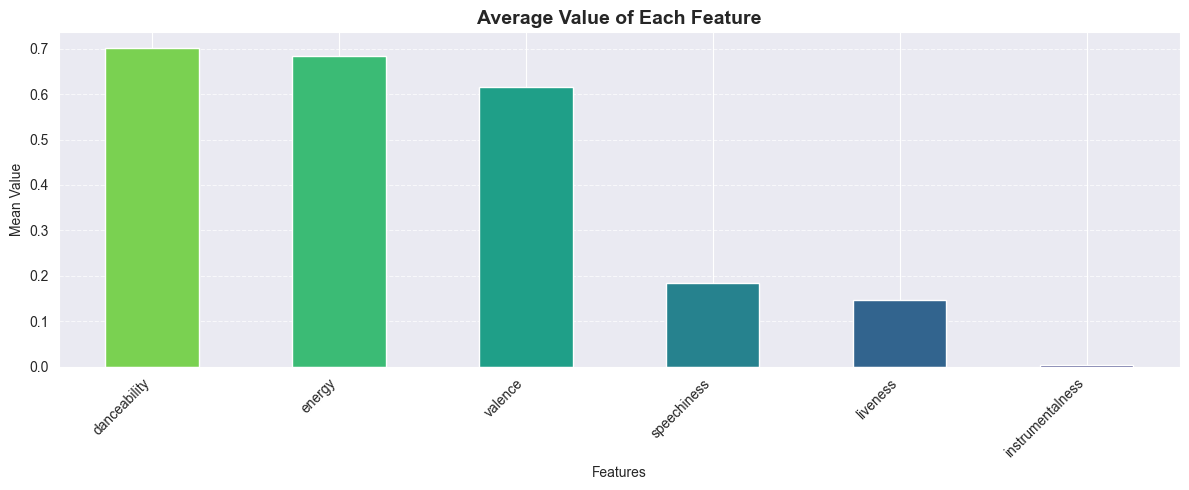

In [119]:
import matplotlib.pyplot as plt

# Example: feature_means is a Pandas Series
feature_means.plot(
    kind='bar',
    figsize=(12,5),
    color=plt.cm.viridis_r(np.linspace(0.2, 0.8, len(feature_means)))  # colorful gradient
)

plt.title('Average Value of Each Feature', fontsize=14, fontweight='bold')
plt.ylabel('Mean Value')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [120]:
# Picking the five attributes  as intrumentalness makes a minor diff
song_features = feature_means.head(5).index.tolist()
print(song_features)


['danceability', 'energy', 'valence', 'speechiness', 'liveness']


In [121]:
#using  these features create a hit score by getting the average of the normalized features
features = ['liveness', 'speechiness', 'danceability', 'energy','valence']

df['hit_score'] = df[features].mean(axis=1)

# # Define a threshold using median
# threshold = df['hit_score'].median()
# df['hit_status'] = (df['hit_score'] >= threshold).astype(int)  # 1 = banger, 0 = flop

df[['track_name', 'hit_score']].head()
df[['track_name', 'hit_score']]

,track_name,hit_score
0,Hello,0.43546
1,Properly (feat. Femi One),0.51370
2,Hapo Tu (feat. Chris Kaiga),0.47182
3,Mungu Pekee,0.49628
4,Bebi Bebi,0.42992
5,Short N Sweet,0.48700
6,Suzanna,0.49618
7,Midnight Train,0.46920
8,Insecure,0.40520
9,Sura Yako,0.52360


## MATHEMATICAL MODELLING USING LINEAR ALGEBRA


In [122]:
#USING GAUSSIAN ELIMINATION METHOD:

features = ['liveness', 'speechiness', 'danceability', 'energy', 'valence']  # 5 features
N = len(features)

# Gaussian elimination with partial pivoting ---
def gaussian_elimination_solve(A_in, b_in, eps=1e-12):
    """
    Solve Ax = b using Gaussian elimination with partial pivoting.
    A_in: (n,n) numpy array
    b_in: (n,) or (n,1) numpy array
    Returns x (n,)
    Raises ValueError if matrix is singular (within tolerance).
    """
    A = A_in.astype(float).copy()
    b = b_in.astype(float).copy().reshape(-1, 1)
    n = A.shape[0]

    # Forward elimination
    for k in range(n):
        # Partial pivoting: find pivot row
        pivot_row = np.argmax(np.abs(A[k:n, k])) + k
        if abs(A[pivot_row, k]) < eps:
            raise ValueError("Matrix is singular or nearly singular (pivot ~ 0).")
        # Swap if needed
        if pivot_row != k:
            A[[k, pivot_row]] = A[[pivot_row, k]]
            b[[k, pivot_row]] = b[[pivot_row, k]]

        # Eliminate below
        for i in range(k+1, n):
            factor = A[i, k] / A[k, k]
            A[i, k:n] = A[i, k:n] - factor * A[k, k:n]
            b[i, 0] = b[i, 0] - factor * b[k, 0]

    # Back substitution
    x = np.zeros((n, 1), dtype=float)
    for i in range(n-1, -1, -1):
        if abs(A[i, i]) < eps:
            raise ValueError("Matrix is singular or nearly singular during back substitution.")
        x[i, 0] = (b[i, 0] - np.dot(A[i, i+1:n], x[i+1:n, 0])) / A[i, i]

    return x.flatten()

# --- Select top-N songs by hit_score to build a square system ---
if df.shape[0] < N:
    raise RuntimeError(f"Not enough rows ({df.shape[0]}) to form a {N}x{N} system.")

topN = df.sort_values('hit_score', ascending=False).head(N)
A = topN[features].values
b = topN['hit_score'].values

print("Top-N track names used for the square system:")
print(topN[['track_name', 'track_id', 'hit_score']])

# --- Solve with Gaussian elimination ---
try:
    coeffs_gauss = gaussian_elimination_solve(A, b)
    coeffs_dict = dict(zip(features, coeffs_gauss))
    print("\nCoefficients found via Gaussian elimination (exact for these chosen rows):")
    for f, c in coeffs_dict.items():
        print(f"  {f}: {c:.6f}")

    # Verify: A @ coeffs_gauss should equal b (within numerical tolerance)
    residual = A.dot(coeffs_gauss) - b
    print("\nResiduals on the chosen top-N rows (A x - b):")
    print(residual)
    print("Max abs residual:", np.max(np.abs(residual)))

    # Apply these coefficients to entire dataset and show top-10 predicted
    X_all = df[features].values
    df['predicted_hit_score_gauss'] = X_all.dot(coeffs_gauss)
    top10_pred = df[['track_name', 'track_id', 'hit_score', 'predicted_hit_score_gauss']]\
                  .sort_values('predicted_hit_score_gauss', ascending=False).head(10)
    print("\nTop 10 by Gaussian solution predicted score:")
    print(top10_pred.to_string(index=False))

except ValueError as e:
    print("Gaussian elimination failed:", e)
    # fallback suggestion: maybe the chosen A is singular; try a different selection or use least-squares
    # Example: try a different set of N independent rows or use np.linalg.lstsq as fallback.
    # You could also try regularization (ridge) with closed form (X^T X + lambda I)^{-1} X^T y.

# --- Optional: check condition number to see stability ---
cond = np.linalg.cond(A)
print(f"\nCondition number of A (top-N): {cond:.3e}")
if cond > 1e12:
    print("Warning: matrix is ill-conditioned; solution may be numerically unstable.")


Top-N track names used for the square system:
              track_name                track_id  hit_score
47  Kamati Ya Roho Chafu  4u6rWAGzucybgRpRWjEb6G    0.62800
40         Shamra Shamra  0zBeSzwKqoZ96EVfltBxp6    0.58352
49           Accelerator  4aLjA8wfNGD07wgZgrpPA2    0.55940
17                  Hepi  2HV7LKVfSS4U9oRLXOoEtv    0.55140
12          Thick Thighs  554GIS5vF1pZXRKymmYrSb    0.55140

Coefficients found via Gaussian elimination (exact for these chosen rows):
  liveness: 0.200000
  speechiness: 0.200000
  danceability: 0.200000
  energy: 0.200000
  valence: 0.200000

Residuals on the chosen top-N rows (A x - b):
[1.11022302e-16 0.00000000e+00 1.11022302e-16 1.11022302e-16
 1.11022302e-16]
Max abs residual: 1.1102230246251565e-16

Top 10 by Gaussian solution predicted score:
                track_name               track_id  hit_score  predicted_hit_score_gauss
      Kamati Ya Roho Chafu 4u6rWAGzucybgRpRWjEb6G    0.62800                    0.62800
             Shamra S

# MACHINE LEARNING MODELLING

In [86]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [87]:
# Features and target
features = ['liveness', 'speechiness', 'danceability', 'energy', 'valence']
X = df[features]
y = df['hit_score']

# Split data 50/50
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)


### 1:Linear Regression

In [123]:
# Initialize and train
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Evaluate
print("Linear Regression:")
print("Coefficients:", dict(zip(features, lr_model.coef_)))
print("Intercept:", lr_model.intercept_)
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))


Linear Regression:
Coefficients: {'liveness': np.float64(0.19999999999999982), 'speechiness': np.float64(0.2), 'danceability': np.float64(0.20000000000000018), 'energy': np.float64(0.19999999999999998), 'valence': np.float64(0.19999999999999987)}
Intercept: 1.1102230246251565e-16
R2 Score: 1.0
MSE: 1.266833918974715e-32


### 2:Random Forest

In [124]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest:")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))


Random Forest:
R2 Score: 0.6332268821237077
MSE: 0.002005393078392596


### 3: Gradient Boosting

In [125]:
# Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("\nGradient Boosting:")
print("R2 Score:", r2_score(y_test, y_pred_gb))
print("MSE:", mean_squared_error(y_test, y_pred_gb))


Gradient Boosting:
R2 Score: 0.7144495070946391
MSE: 0.0015612948553038425


In [126]:
comparison = pd.DataFrame({
    'track_name': df.loc[y_test.index, 'track_name'],
    'actual_hit_score': y_test,
    'pred_lr': y_pred_lr,
    'pred_rf': y_pred_rf,
    'pred_gb': y_pred_gb
})

print(comparison.sort_values('actual_hit_score', ascending=False).head(10))


              track_name  actual_hit_score  pred_lr   pred_rf   pred_gb
47  Kamati Ya Roho Chafu           0.62800  0.62800  0.516200  0.532129
49           Accelerator           0.55940  0.55940  0.535119  0.556569
17                  Hepi           0.55140  0.55140  0.472202  0.478895
12          Thick Thighs           0.55140  0.55140  0.475641  0.486741
43               Tarimbo           0.55020  0.55020  0.537514  0.545213
36       Such Kinda Love           0.52830  0.52830  0.504213  0.493637
30                Rewind           0.52440  0.52440  0.504241  0.495907
9              Sura Yako           0.52360  0.52360  0.515224  0.518592
50               KISHASH           0.51000  0.51000  0.459717  0.473080
3            Mungu Pekee           0.49628  0.49628  0.505456  0.498967


## Top 10 songs using linear regression

In [135]:
# Add predicted hit scores for test set
df.loc[y_test.index, 'predicted_hit_score_lr'] = y_pred_lr

#Sort and display
top_10_lr = df.loc[y_test.index, ['track_name', 'hit_score', 'predicted_hit_score_lr']]\
    .sort_values('predicted_hit_score_lr', ascending=False).head(10)

print(top_10_lr)


              track_name  hit_score  predicted_hit_score_lr
47  Kamati Ya Roho Chafu     0.6280                  0.6280
49           Accelerator     0.5594                  0.5594
17                  Hepi     0.5514                  0.5514
12          Thick Thighs     0.5514                  0.5514
43               Tarimbo     0.5502                  0.5502


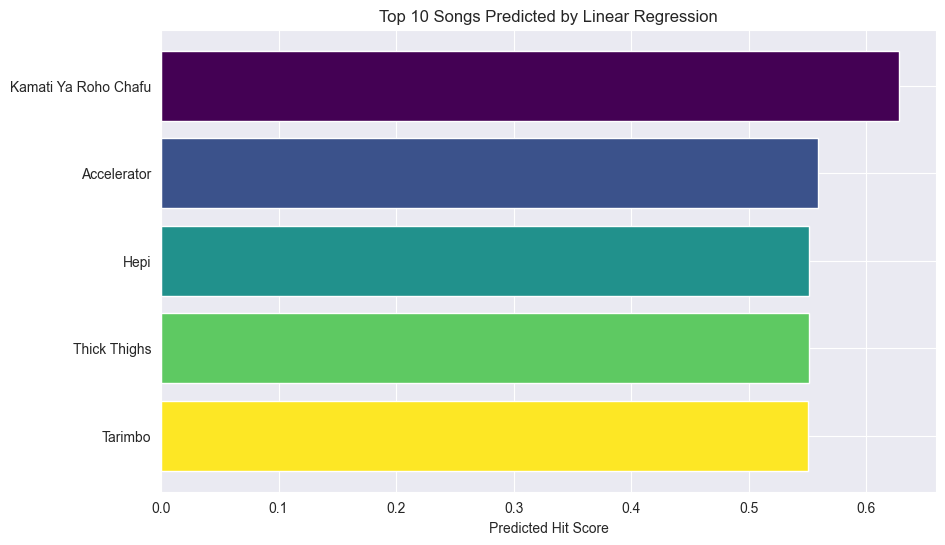

In [136]:
plt.figure(figsize=(10,6))
plt.barh(
    top_10_lr['track_name'],
    top_10_lr['predicted_hit_score_lr'],
    color=plt.cm.viridis(np.linspace(0, 1, len(top_10_lr)))
)
plt.xlabel('Predicted Hit Score')
plt.title('Top 10 Songs Predicted by Linear Regression')
plt.gca().invert_yaxis()  # highest on top
plt.show()


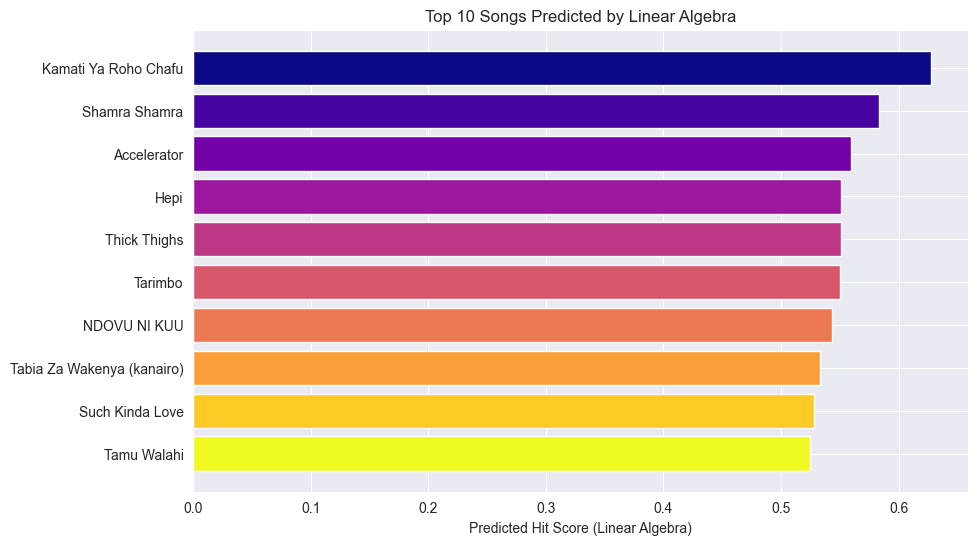

In [137]:

plt.figure(figsize=(10,6))
plt.barh(top_10_la['track_name'], top_10_la['predicted_hit_score'], color=plt.cm.plasma(np.linspace(0, 1, len(top_10_la))))
plt.xlabel('Predicted Hit Score (Linear Algebra)')
plt.title('Top 10 Songs Predicted by Linear Algebra')
plt.gca().invert_yaxis()  # highest on top
plt.show()

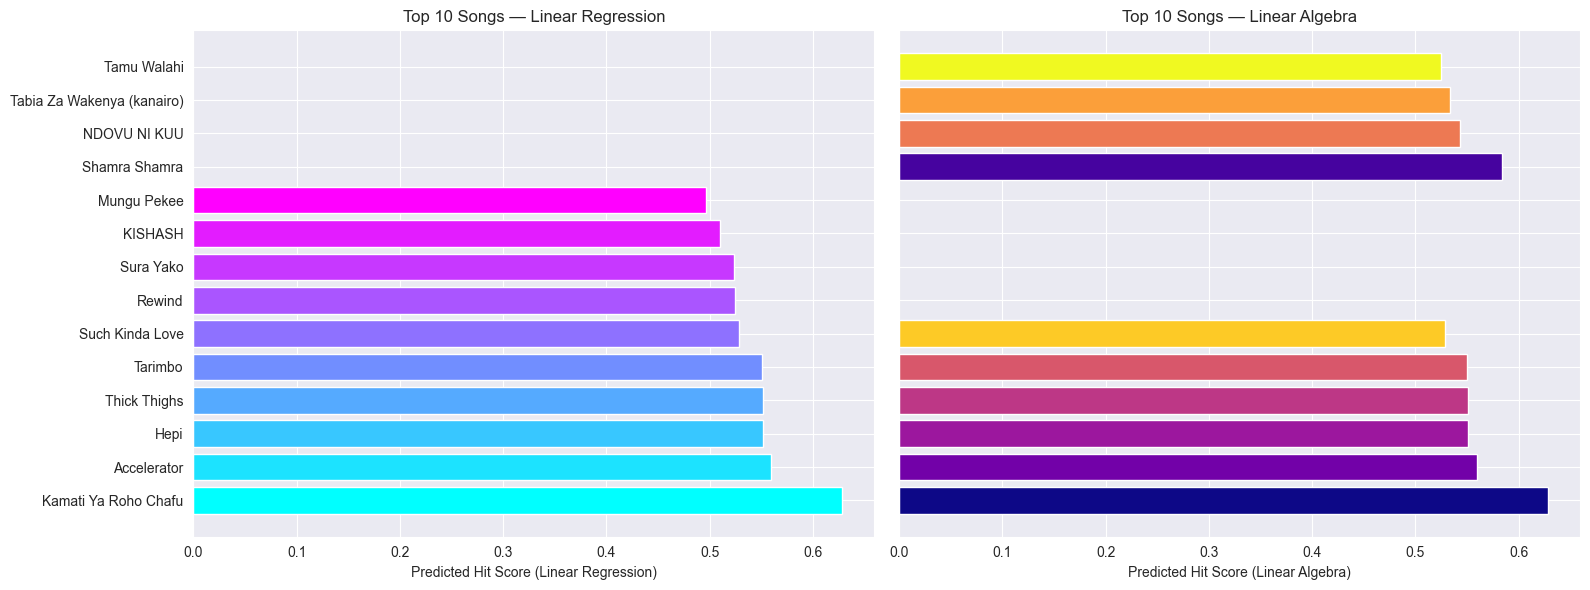

In [134]:

# Creating the top ten Linear regression and linear algebra side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- Linear Regression ---
axes[0].barh(top_10_lr['track_name'], top_10_lr['predicted_hit_score_lr'], color=plt.cm.cool(np.linspace(0, 1, len(top_10_lr))))
axes[0].set_xlabel('Predicted Hit Score (Linear Regression)')
axes[0].set_title('Top 10 Songs — Linear Regression')
axes[0].invert_yaxis()  # Highest on top

# --- Linear Algebra ---
axes[1].barh(top_10_la['track_name'], top_10_la['predicted_hit_score'], color=plt.cm.plasma(np.linspace(0, 1, len(top_10_la))))
axes[1].set_xlabel('Predicted Hit Score (Linear Algebra)')
axes[1].set_title('Top 10 Songs — Linear Algebra')
axes[1].invert_yaxis()

# Improve layout
plt.tight_layout()
plt.show()


# Merge top 10 Linear Algebra and Linear Equation


In [100]:
# Merge on track_name to see differences
comparison_top10 = pd.merge(
    top_10_lr[['track_name', 'predicted_hit_score_lr']],
    top_10_la[['track_name', 'predicted_hit_score']],
    on='track_name',
    how='outer'
)

# Fill missing values with 0 (if some songs are only in one list)
comparison_top10 = comparison_top10.fillna(0)

# Add difference column
comparison_top10['score_diff'] = comparison_top10['predicted_hit_score_lr'] - comparison_top10['predicted_hit_score']

# Sort by Linear Regression predicted score
comparison_top10 = comparison_top10.sort_values('predicted_hit_score_lr', ascending=False)

print(comparison_top10)


                    track_name  predicted_hit_score_lr  predicted_hit_score  \
3         Kamati Ya Roho Chafu                 0.62800              0.62800   
0                  Accelerator                 0.55940              0.55940   
1                         Hepi                 0.55140              0.55140   
13                Thick Thighs                 0.55140              0.55140   
12                     Tarimbo                 0.55020              0.55020   
8              Such Kinda Love                 0.52830              0.52830   
6                       Rewind                 0.52440              0.00000   
9                    Sura Yako                 0.52360              0.00000   
2                      KISHASH                 0.51000              0.00000   
4                  Mungu Pekee                 0.49628              0.00000   
5                 NDOVU NI KUU                 0.00000              0.54340   
7                Shamra Shamra                 0.000

In [138]:
# Coefficients from Linear Regression
lr_importance = pd.Series(lr_model.coef_, index=features).sort_values(ascending=False)
print("Linear Regression Coefficients\n", lr_importance)




Linear Regression Coefficients
 danceability    0.2
speechiness     0.2
energy          0.2
valence         0.2
liveness        0.2
dtype: float64
